# FP8 and the $Lmul$ Algorithm

This notebook serves to summarize the work we have done so far with the 8-bit floating point format and reimplementing the $Lmul$ algorithm for fast floating point multiplication from the paper [Addition is All You Need](https://arxiv.org/pdf/2410.00907). Helper code is located in the `.py` files in this directory.  

We perform an analysis of of the accuracy of the $Lmul$ algorithm with fp8, simply run all cells to reproduce the results easily.

## Explaining the 8-Bit Float Format

### Open Compute Project FP8 Specification

OFP8 representation consists of sign, exponent, and mantissa fields. In this specification we
use the term mantissa to refer to the trailing significand bits. Two encodings are defined - E4M3
and E5M2, where the name explicitly states the number of bits in the exponent (E) and mantissa
(M) fields. Encodings consist of:

- 1 sign bit: the most significant bit
- e-bit biased exponent: 4 bits for E4M3, 5 bits for E5M2
- m mantissa (trailing significand) bits: 3 bits for E4M3, 2 bits for E5M2

The value, v, of a normal OFP8 number is
$$ v = (−1)^S × 2^{E−bias} × (1 + 2^{−m} × M) $$
The value, v, of a subnormal OFP8 number (subnormals have E = 0 and M > 0) is
$$ v = (−1)^S × 2^{1−bias} × (0 + 2^{−m} × M) $$

Exponent parameters and min/max values for both OFP8 formats are specified in Table 1.
The E5M2 format represents infinities and NaNs. Interpretation of the three mantissa values for
NaNs is not defined. The E4M3 format does not represent infinities and uses only two bit
patterns for NaN (a single mantissa-exponent bit pattern but allowing both values of the sign bit)
in order to increase emax to 8 and thus to increase the dynamic range by one binade. Various
values for OFP8 formats are detailed in Table 2.

### Table 1: OFP8 exponent parameters

| Parameter       | E4M3 | E5M2 |
| --------------- | ---- | ---- |
| Exponent bias   | 7    | 15   |
| emax (unbiased) | 8    | 15   |
| emin (unbiased) | -6   | -14  |

### Table 2: OFP8 value encoding details

| Parameter            | E4M3                        | E5M2                        |
| -------------------- | --------------------------- | --------------------------- |
| Infinities           | N/A                         | S.11111.00₂                 |
| NaN                  | S.1111.111₂                 | S.11111.{01, 10, 11}₂       |
| Zeros                | S.0000.000₂                 | S.00000.00₂                 |
| Max normal number    | S.1111.110₂ = ±448          | S.11110.11₂ = ±57,344       |
| Min normal number    | S.0001.000₂ = ±2⁻⁶          | S.00001.00₂ = ±2⁻¹⁴         |
| Max subnormal number | S.0000.111₂ = ±0.875 \* 2⁻⁶ | S.00000.11₂ = ±0.75 \* 2⁻¹⁴ |
| Min subnormal number | S.0000.001₂ = ±2⁻⁹          | S.00000.01₂ = ±2⁻¹⁶         |
| Dynamic range        | 18 binades                  | 32 binades                  |


We should note that there are other formats for FP8 as well ([Tesla Dojo CFloat8](https://digitalassets.tesla.com/tesla-contents/image/upload/tesla-dojo-technology.pdf)), but this is the most similar to the standards defined in IEEE 754.  

Since `float8` is not a common or built-in datatype, we wrote a custom class for working with the format, lets import that below. We should also note that although the E4M3 format does not support infinities, we have decided to treat sequences of all 1's as $\pm \inf$.

In [1]:
from float8 import Float8

## Standard Floating point multiplication

A floating point number can be represented with a sign bit $s$, exponent bits $e$, bias $b$ and mantissa bits $m$ where the value $v$ is is calculated as:

$$
v = (-1)^{\textstyle s} \times 2^{\textstyle (e-b)} \times (1+m) \\
$$

We can use the following equation to multiply two floats together:

$$
p = (s_1 \oplus s_2) \times 2^{\textstyle (e_1+e_2-2b)} \times (1+m_1+m_2+m_1 m_2)
$$

Since the exponent bit representations ($e_1$ and $e_2$) are biased, we need to subtract the bias ($b$) to get the actual exponent value, otherwise the bias is counted twice.

$$
e_{\text{unbiased}} = e_1 + e_2 - 2b \\
e_{\text{bits}} = e_{\text{unbiased}} + b \\
e_{\text{bits}} = e_1 + e_2 - b \\
$$


## $Lmul$ Floating point multiplication algorithm

The core idea of the $Lmul$ algorithm is that we can elimate the multiplication of $m_1 \times m_2$ by approximating it with a term $L(M)$ where $M$ is the number of mantissa bits.  
The $L$ function is defined as:

$$
\begin{equation}
 L(M) =
   \left\{\begin{array}{lr}
       M, & M \le 3 \\
       3, & M = 4 \\
       4, & M \gt 4 \\
    \end{array}\right.
 \end{equation}
$$

The multiplication algorithm becomes:  
$$ (s_1 \oplus s_2) \times 2^{\textstyle (e_1+e_2-b)} \times (1+m_1+m_2+L(M)) $$

In practice, we can perform this algorithm by taking the $XOR$, and performing a bitwise addition on the combined exponent and mantissa parts, adding the $L(M)$ term, and subtracting the bias bitshifted to the left to align with the exponent part. This enables us to skip the normalization step since the mantissa carry is automatically added to the exponent.

Lets import the function we designed to perform this algorithm on FP8 numbers. 
> Note that it is a simple implentation that doesn't handle all the edge cases correctly, but according to the paper, they also used a simple implementation to achieve their results.

In [52]:
from lmul import fp8_lmul_simple

### A note on Subnormals


For now, we are not handling subnormal numbers and treating them as 0. We will handle them later. We think this approach is correct, but are still working on it:

A subnormal number is represented with exponent $e=0$ and defined as:
$$ (-1)^s \times 2^{e+1-b} \times (0+m) $$

Multiplying two subnormal numbers will always underflow to 0, but multiplying a normal $\times$ subnormal can result in 0, subnormal, or normal. The multiplication of a normal number $x$ and subnormal number $y$ with $y_e=0$ looks like:

$$
(x_s \oplus y_s) \times 2^{\textstyle (x_e+1-b)} \times (0+y_m)(1+x_m) \\
$$

The mantissa portion becomes: $(0 + y_m + y_m x_m) = (y_m + L(M))$



## Testing the accuracy of $Lmul$

Lets test the error of the $Lmul$ algorithm for all normal FP8 numbers. First, lets generate a list that holds a combination of every possible combination of normal numbers.

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations, product, combinations_with_replacement

In [50]:
def generate_normal_fp8_list():
    fp8_list = [Float8(0)]
    for s in range(2):
        for e in range(1,16):
            for m in range(8):
                sign = format(s, '01b')
                exponent = format(e, '04b')
                mantissa = format(m, '03b')
                fp8_list.append(Float8(sign + exponent + mantissa))
        # When all bits are 1, it represents inf, we can exclude these
        fp8_list.pop(-1)
    return fp8_list

def generate_all_normal_combinations():
    fp8_list = generate_normal_fp8_list()
    # Generate all combinations of fp8_list with itself
    return list(combinations_with_replacement(fp8_list, 2))

def generate_combinations_for_heatmap():
    fp8_list = [Float8(0)]
    for s in range(2):
        for e in range(1,16):
            for m in [0,7]:
                sign = format(s, '01b')
                exponent = format(e, '04b')
                mantissa = format(m, '03b')
                fp8_list.append(Float8(sign + exponent + mantissa))
    return list(combinations_with_replacement(fp8_list, 2))

def test_combinations(test_cases: list[tuple[Float8, Float8]], multiply_func):
    # Test all possible combinations of subnormal and normal numbers
    # test_cases = generate_all_normal_combinations()
    # test_cases = generate_combinations_for_heatmap()
    results = []
    for x, y in test_cases:
            true_result = x * y
            calculated_result = multiply_func(x, y)
            results.append({
                "x_binary": x.binary,
                "y_binary": y.binary,
                "x_decimal": x.decimal,
                "y_decimal": y.decimal,
                "true_result_binary": true_result.binary,
                "true_result": true_result.decimal,
                "true_result_decimal_approx": true_result.decimal_approx,
                "calculated_result": calculated_result.decimal,
                "calculated_result_binary": calculated_result.binary,
                # We calculate the error using the decimal approximations from the binary representations
                # since by nature of the FP8 format it cannot accurately represent all decimal numbers
                "error": calculated_result.decimal_approx - true_result.decimal_approx,
                "true_total_error": calculated_result.decimal - true_result.decimal,
            })

    df = pd.DataFrame(results)
    return df

In [53]:
all_normals = generate_all_normal_combinations()
subset_normals = generate_combinations_for_heatmap()

df_normals = test_combinations(all_normals, fp8_lmul_simple)
df_normals

,x_binary,y_binary,x_decimal,y_decimal,true_result_binary,true_result,true_result_decimal_approx,calculated_result,calculated_result_binary,error,true_total_error
0,0.0000.000,0.0000.000,0.0,0.000000,0.0000.000,0.0,0.0,0.0,0.0000.000,0.0,0.0
1,0.0000.000,0.0001.000,0.0,0.015625,0.0000.000,0.0,0.0,0.0,0.0000.000,0.0,0.0
2,0.0000.000,0.0001.001,0.0,0.017578,0.0000.000,0.0,0.0,0.0,0.0000.000,0.0,0.0
3,0.0000.000,0.0001.010,0.0,0.019531,0.0000.000,0.0,0.0,0.0,0.0000.000,0.0,0.0
4,0.0000.000,0.0001.011,0.0,0.021484,0.0000.000,0.0,0.0,0.0,0.0000.000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
28675,1.1111.100,1.1111.101,-384.0,-416.000000,0.1111.111,inf,inf,inf,0.1111.111,NaN,NaN
28676,1.1111.100,1.1111.110,-384.0,-448.000000,0.1111.111,inf,inf,inf,0.1111.111,NaN,NaN
28677,1.1111.101,1.1111.101,-416.0,-416.000000,0.1111.111,inf,inf,inf,0.1111.111,NaN,NaN
28678,1.1111.101,1.1111.110,-416.0,-448.000000,0.1111.111,inf,inf,inf,0.1111.111,NaN,NaN


Since there are not that many total representable values using the FP8 format (max 256), we can plot a heatmap of the error for every combination of multiplications.

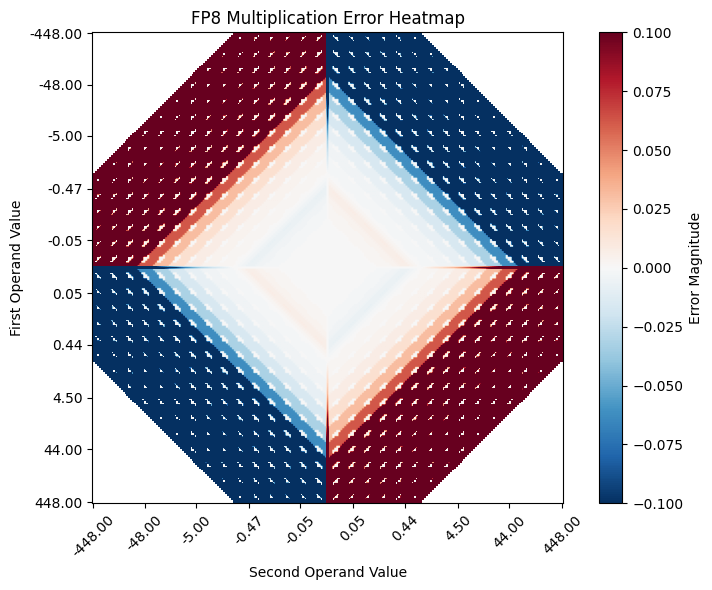

In [54]:
def plot_multiplication_error_heatmap(df):
    # Create matrices for x and y values to plot
    unique_values = sorted(list(set(df['x_decimal'].unique()) | set(df['y_decimal'].unique())))
    n = len(unique_values)
    error_matrix = np.zeros((n, n))
    
    # Fill the error matrix
    value_to_index = {val: idx for idx, val in enumerate(unique_values)}
    for _, row in df.iterrows():
        i = value_to_index[row['x_decimal']]
        j = value_to_index[row['y_decimal']]
        error_matrix[i, j] = row['error']
        # Make the matrix symmetric since multiplication is commutative
        error_matrix[j, i] = row['error']
    
    # Create the heatmap
    plt.figure(figsize=(8, 6))
    
    # Use diverging colormap with white at center
    max_abs_error = np.max(np.abs(error_matrix))
    heatmap = plt.imshow(error_matrix, 
                        cmap='RdBu_r',  # Red-White-Blue colormap
                        aspect='equal',
                        vmin=-max_abs_error,
                        vmax=max_abs_error)
    
    # Add colorbar
    plt.colorbar(heatmap, label='Error Magnitude')
    
    # Customize the plot
    plt.title('FP8 Multiplication Error Heatmap')
    plt.xlabel('Second Operand Value')
    plt.ylabel('First Operand Value')
    
    # Set tick labels (use fewer ticks for readability)
    tick_indices = np.linspace(0, n-1, min(10, n)).astype(int)
    plt.xticks(tick_indices, [f'{unique_values[i]:.2f}' for i in tick_indices], rotation=45)
    plt.yticks(tick_indices, [f'{unique_values[i]:.2f}' for i in tick_indices])
    
    plt.tight_layout()
    plt.show()

plot_multiplication_error_heatmap(df_normals)

We can see that the largest magnitude errors generally occur when multiplying a small and large number together. Generally errors tend to be lower when multiplying smaller values, which is good since the application of this algorithm is for machine learning models whose weights tend to be in well defined ranges like $[0,1]$ or $[-1,1]$.

## Extending the $Lmul$ Algorithm to handle subnormals

Here we attempt to extend the $Lmul$ algorithm to handle the case when a normal number is multiplied by a subnormal. Just like the case where we multiply two normal numbers, multiplying a normal by a subnormal can result in either 0, subnormal, or normal. This algorithm is slightly more complex since we need to explicitly handle some additional steps like normalization of the mantissa and exponent.  

Due to these extra steps, and the fact that the paper where we learned about this algorithm does not account for subnormals and was still able to achieve high accuracy when actually implementing the $Lmul$ algorithm with LLMs, we will likely NOT implement this in hardware as it adds a lot of extra circuitry for little benefit. We may be able to dynamically modify the offset value $L(M)$ to account for subnormals instead but we need to find a good alternative value first.

> Note that this might not be completely correct yet, we are still working to verify the optimal solution

### Algorithm Steps

The code implements multiplication between normal and subnormal FP8 numbers using the following algorithm:

1. Extract components from inputs x and y:
   - Sign bits: $s_x$, $s_y$ 
   - Exponents: $e_x$, $e_y$
   - Mantissas: $m_x$, $m_y$

2. Calculate result sign using XOR:
   $s_{result} = s_x \oplus s_y$

3. If either number is subnormal ($e_x = 0$ or $e_y = 0$):
   
   a. Identify the subnormal and normal numbers:
      - Subnormal: $m_{sub}$ (mantissa), $e_{sub}=0$
      - Normal: $m_{norm}$ (mantissa), $e_{norm}$
   
   b. Normalize the subnormal mantissa:
      - Add offset: $m_{sub} = m_{sub} + L(M)$
      - Find left shift amount $k$ to normalize
      - Shift: $m_{sub\_norm} = m_{sub} \ll k$
   
   c. Calculate result mantissa:
      $m_{result} = m_{norm} + m_{sub\_norm}$
   
   d. Handle mantissa overflow:
      - If $m_{result}$ overflows, right shift by 1 and increment $k$
   
   e. Calculate result exponent:
      - Subnormal adjusted exponent: $e_{sub\_adj} = (1-bias) - k$
      - Final exponent: $e_{result} = e_{norm} + e_{sub\_adj}$
   
   f. Handle result denormalization if $e_{result} \leq 0$:
      - Denormalization shift: $d = 1 - e_{result}$
      - $m_{result} = ((1 \ll M) + m_{result}) \gg d$
      - $e_{result} = 0$

4. Combine components into final result:
   $result = (s_{result} \ll (P-1)) | (e_{result} \ll M) | m_{result}$

where:
- $M$ is mantissa bits (3)
- $P$ is total precision (8)
- $bias$ is exponent bias (7)
- $L(M)$ is the Lmul offset function


### Algorithm Code:

In [60]:
from lmul import get_lmul_offset
from float8 import Float8

def get_shift_amount(mantissa: int, m_bits: int) -> int:
    # If mantissa is 0, no shift will make it normalized
    if mantissa == 0:
        return 0
        
    # Find position of leftmost 1 by checking each bit
    # from left to right
    for i in range(m_bits):
        if mantissa & (1 << (m_bits - i)):
            # Return number of shifts needed to get leftmost 1
            # to implied position
            return i
            
    return m_bits # In case no 1 is found

def lmul_normal_subnormal(x:Float8, y:Float8) -> Float8:
    # Constants for e4m3 format
    E_BITS = 4
    M_BITS = 3
    PRECISION = 1 + E_BITS + M_BITS
    BIAS = 7  # 2^(4-1) - 1
    EXP_MASK = (1 << E_BITS) - 1
    MANTISSA_MASK = (1 << M_BITS) - 1
        
    # Step 0: Check for subnormal inputs
    x_exp = (x.binint >> M_BITS) & EXP_MASK
    y_exp = (y.binint >> M_BITS) & EXP_MASK
    x_mantissa = x.binint & MANTISSA_MASK
    y_mantissa = y.binint & MANTISSA_MASK
    
    # Step 1: Handle sign bit
    sign_x = (x.binint >> 7) & 1
    sign_y = (y.binint >> 7) & 1
    result_sign = sign_x ^ sign_y
    
    if x_exp == 0 or y_exp == 0:
        # 0. Identify subnormal and normal numbers
        subnormal_mantissa = x_mantissa if x_exp == 0 else y_mantissa
        normal_mantissa = y_mantissa if x_exp == 0 else x_mantissa
        normal_exp = y_exp if x_exp == 0 else x_exp
        
        # First normalize the subnormal mantissa
        subnormal_mantissa += get_lmul_offset(M_BITS)
        norm_shift = get_shift_amount(subnormal_mantissa, M_BITS)
        normalized_mantissa = (subnormal_mantissa << norm_shift) & MANTISSA_MASK
        
        # Calculate the result mantissa from normalized values
        result_mantissa = normal_mantissa + normalized_mantissa #+ get_lmul_offset(M_BITS)
        
        # Check if the mantissa addition step resulted in an overflow
        if result_mantissa > MANTISSA_MASK:
            result_mantissa &= MANTISSA_MASK
            result_mantissa >>= 1
            norm_shift += 1
        
         # 2. Adjusted exponent for normalized subnormal
        subnorm_adj_exp = (1 - BIAS) - norm_shift
        
        # 3. Calculate the result exponent
        result_exp = normal_exp + subnorm_adj_exp
        
        # Check for 0 exponent after addition, which means the result is denormalized
        if result_exp <= 0:
            # Denormalize result
            denorm_shift = 1 - result_exp
            result_mantissa = ((1<<M_BITS)+result_mantissa) >> denorm_shift
            result_exp = 0

    # Combine results
    result = (result_sign << PRECISION-1) | (result_exp << M_BITS) | result_mantissa

    return Float8.from_binint(result)

### Testing subnormal $\times$ normal cases

We can generate every possible pair of normal and subnormal numbers as we did above and plot a heatmap of the errors to see how well this new algorithm handles them.

In [56]:
def generate_all_subnormals():
    subnormals = []
    for s in range(2):
        for m in range(1,8):
            sign = format(s, '01b')
            exponent = '0000'
            mantissa = format(m, '03b')
            subnormals.append(Float8(sign + exponent + mantissa))
    return subnormals

def generate_normal_subnormal_combinations():
    subnormals = generate_all_subnormals()
    normals = generate_normal_fp8_list()
    return list(product(normals, subnormals))

normal_subnormals = generate_normal_subnormal_combinations()

In [57]:
def plot_normal_subnormal_error_heatmap(df):
    # Get unique normal and subnormal values
    normal_values = sorted(df['x_decimal'].unique())
    subnormal_values = sorted(df['y_decimal'].unique())
    
    # Create the error matrix
    error_matrix = np.zeros((len(subnormal_values), len(normal_values)))
    
    # Create mapping dictionaries for quick index lookup
    normal_to_idx = {val: idx for idx, val in enumerate(normal_values)}
    subnormal_to_idx = {val: idx for idx, val in enumerate(subnormal_values)}
    
    # Fill the error matrix
    for _, row in df.iterrows():
        i = subnormal_to_idx[row['y_decimal']]  # subnormal on y-axis
        j = normal_to_idx[row['x_decimal']]     # normal on x-axis
        error_matrix[i, j] = row['error']
    
    # Create the plot
    plt.figure(figsize=(15, 6))
    
    # Get true min and max errors
    max_error = df['error'].max()
    min_error = df['error'].min()
    abs_max = max(abs(max_error), abs(min_error))
    
    # Create heatmap
    heatmap = plt.imshow(error_matrix, 
                        cmap='RdBu_r',
                        aspect='auto',  # Changed from 'equal' to 'auto' for non-square matrix
                        vmin=-abs_max,
                        vmax=abs_max)
    
    # Add colorbar
    plt.colorbar(heatmap, label='Error Magnitude')
    
    # Customize the plot
    plt.title('Normal × Subnormal FP8 Multiplication Error Heatmap')
    plt.xlabel('Normal Number Value')
    plt.ylabel('Subnormal Number Value')
    
    # Set tick labels (use fewer ticks for readability)
    # For x-axis (normal values)
    n_normal_ticks = min(10, len(normal_values))
    normal_tick_indices = np.linspace(0, len(normal_values)-1, n_normal_ticks).astype(int)
    plt.xticks(normal_tick_indices, 
               [f'{normal_values[i]:.2f}' for i in normal_tick_indices], 
               rotation=45)
    
    # For y-axis (subnormal values), show all since there are only 14
    plt.yticks(range(len(subnormal_values)), 
               [f'{val:.6f}' for val in subnormal_values])
    
    plt.tight_layout()
    plt.show()

We can plot another heatmap to visualize the errors

First lets try using our basic $Lmul$ algorithm

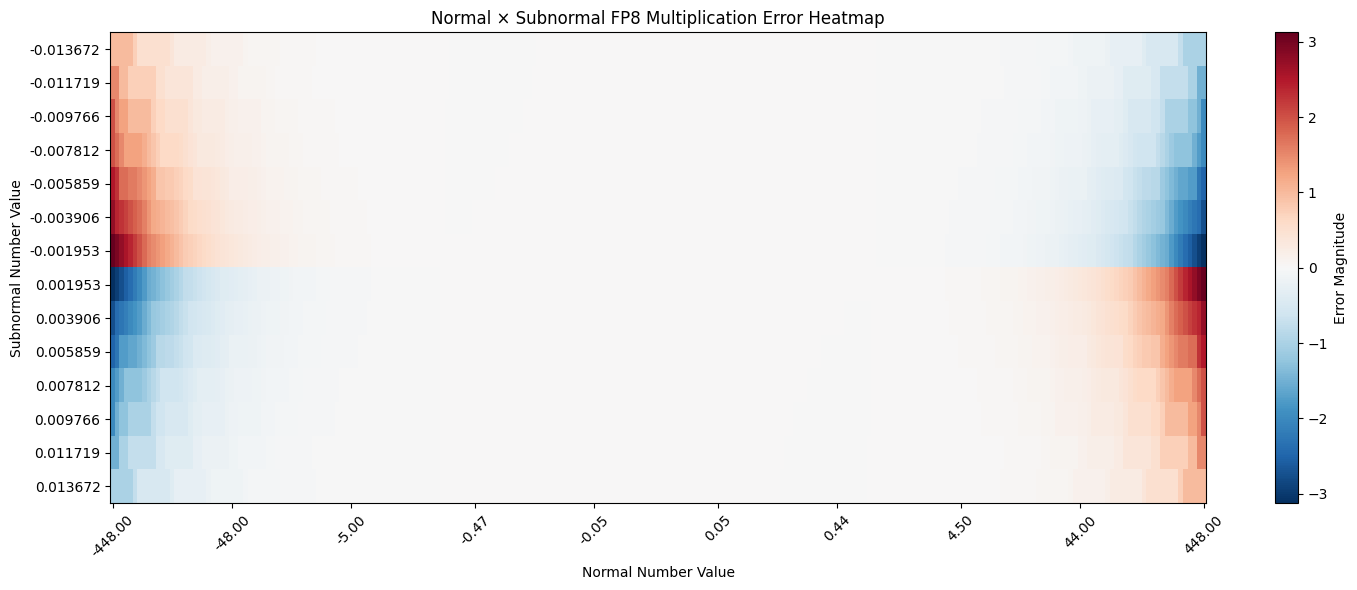

In [58]:
df_subnormals_naiive = test_combinations(normal_subnormals, fp8_lmul_simple)
plot_normal_subnormal_error_heatmap(df_subnormals_naiive)

Now with the new algorithm designed to handle subnormals

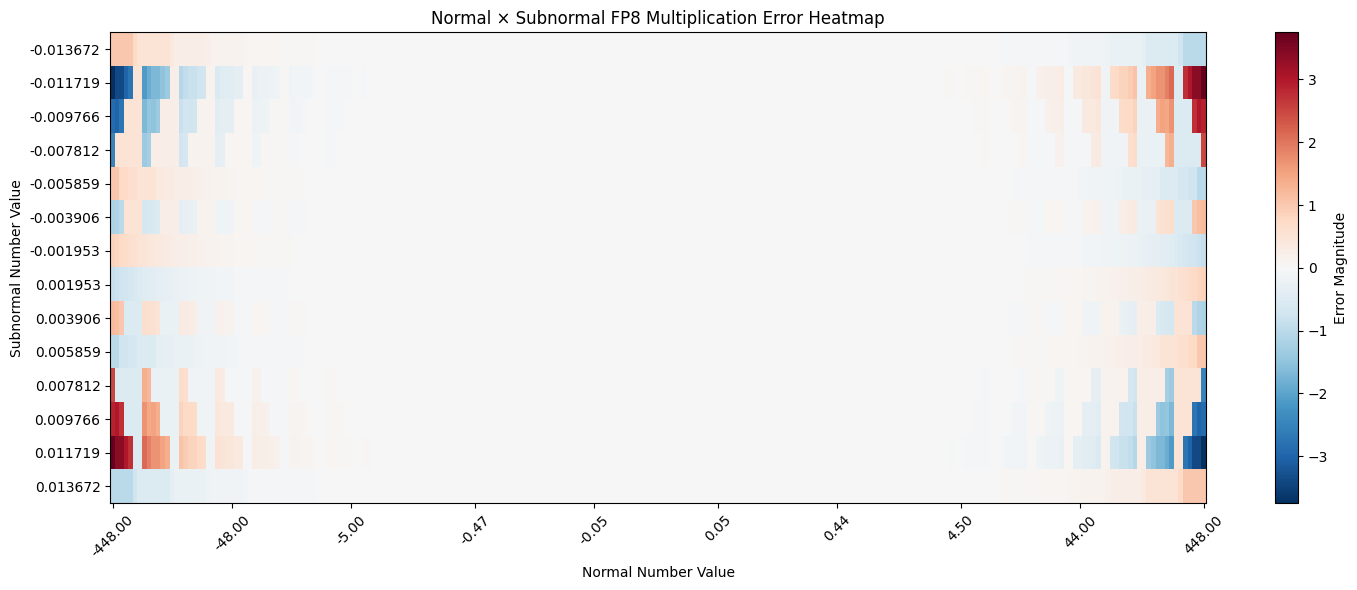

In [61]:
df_subnormals = test_combinations(normal_subnormals, lmul_normal_subnormal)
plot_normal_subnormal_error_heatmap(df_subnormals)

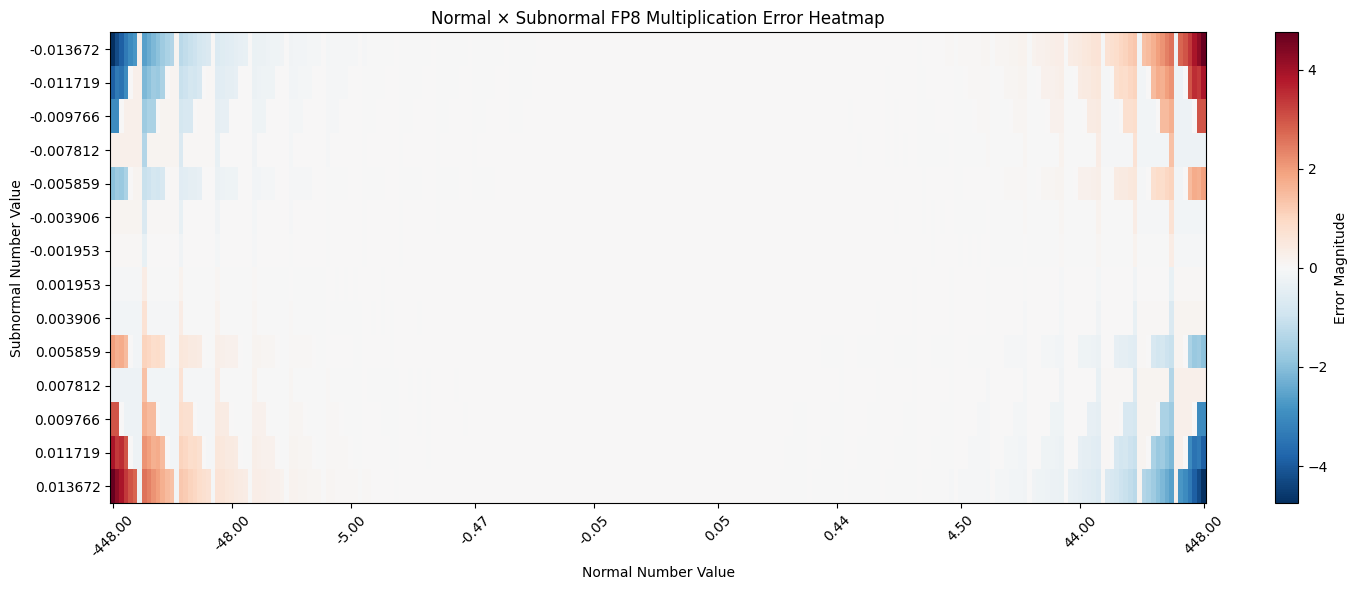

In [ ]:
df_subnormals = test_combinations(normal_subnormals, lmul_normal_subnormal)
plot_normal_subnormal_error_heatmap(df_subnormals)

Clearly the distribution of errors is quite different between the two algorithms. Not too sure what is going on here just yet.

## A Basic Hardware Implementation

Right now, we have just been simulating how this algorithm works at a very high level in Python, but the real performance gains will come from implementing this on hardware. It is not really feasible to get a good performance gain using just software, since model weights stored in floating point formats will be interpreted as such by whatever hardware they are run on (GPU, CPU, etc) and need to be cast to some other representation, sent through multiple different datapaths on chip that are probably not optimized for performing very parallel matrix multiplies, and would increase on chip IO and likely actually be slower than just using the existing floating point units. 

We need to design those floating point units to use this algorithm at the very lowest level to see meaningful gains, this is our starting point.  

Typically, hardware is designed with a HDL (hardware description language) such as Verilog or VHDL. Since we are data science students, we do not know these languages. Thankfully, the open source community has blessed us Pythonistas with an easy to use Pythonic HDL called [PyRTL](https://github.com/UCSBarchlab/PyRTL). PyRTL lets you build hardware that you explicitly define with their built in classes. It provides support for design, simulation, and synthesis.  

We have implemented the naiive $Lmul$ algorithm described above in PyRTL. The code is in the `lmul_hardware.py` file.

In [5]:
import pyrtl
from lmul_hardware import lmul_rtl
from IPython.display import display_svg

We can build the hardware by calling the function `lmul_rtl`. PyRTL conveniently provides us with a way to visualize our hardware as a block diagram, lets render it below:

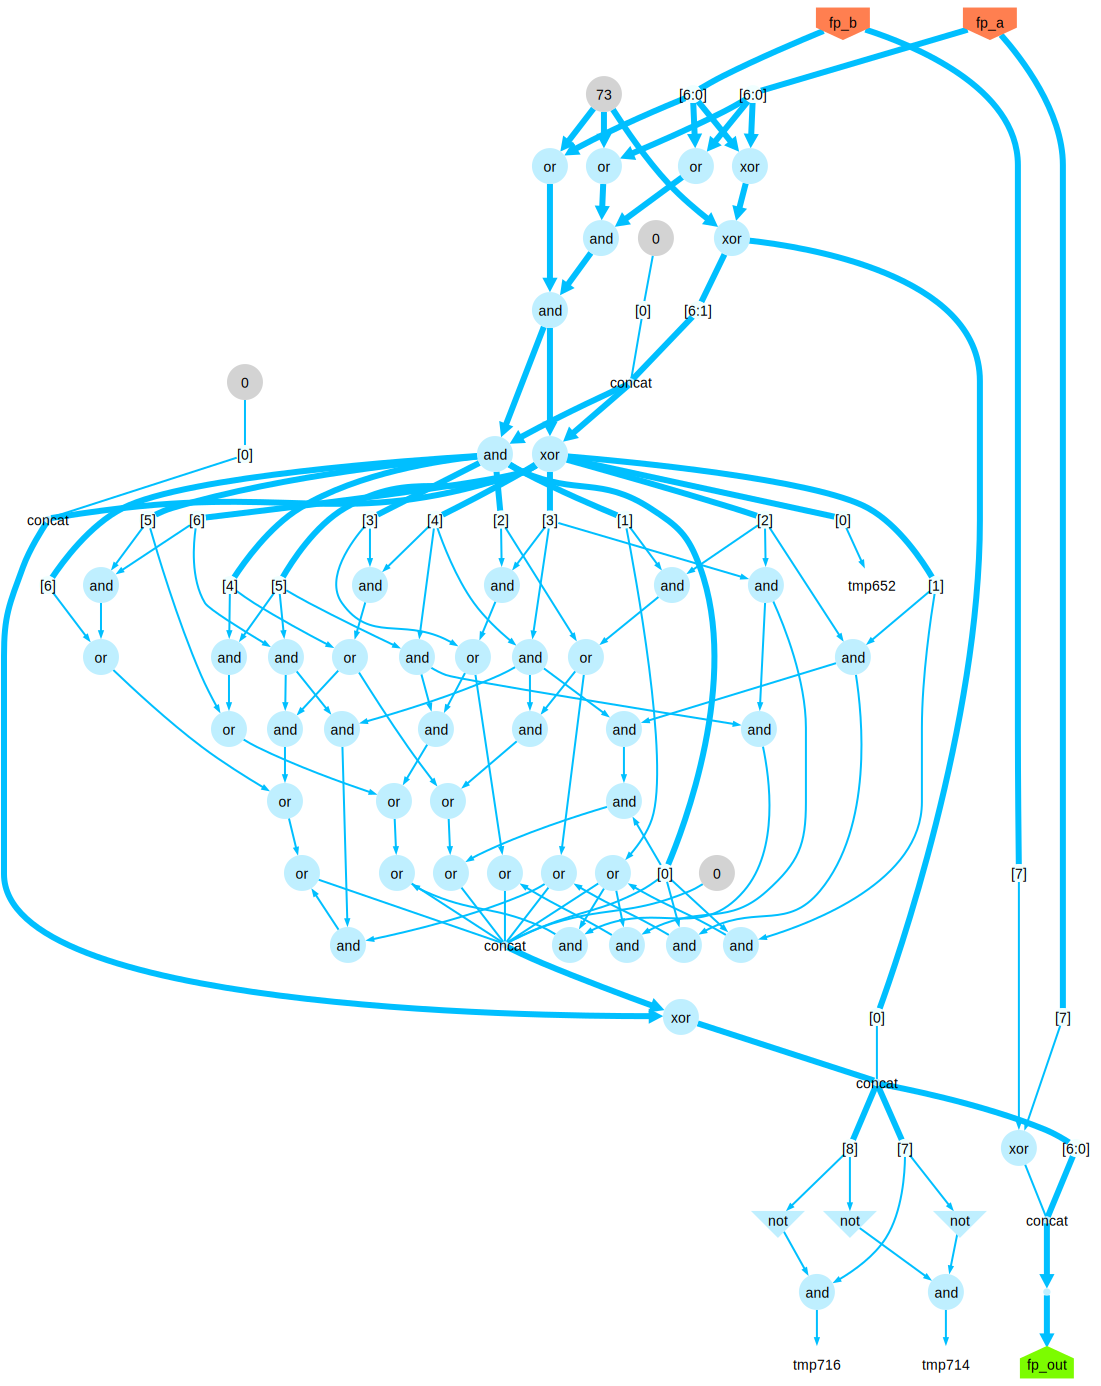

In [8]:
# Create the hardware
pyrtl.reset_working_block()
fp_a, fp_b, fp_out = lmul_rtl()

svg = pyrtl.block_to_svg(maintain_arg_order=True)
display_svg(svg, raw=True)

Next we can use PyRTL's tooling to analyze the timing and area requirements of the circuit. They provide built in optimization functions that we can utilize as well. Lets see the characteristics before and after running the optimization.

In [9]:
pyrtl.synthesize()

# Generating timing analysis information
print("Pre Optimization:")
timing = pyrtl.TimingAnalysis()
timing.print_max_length()
logic_area, mem_area = pyrtl.area_estimation(tech_in_nm=65)
est_area = logic_area + mem_area
print("Estimated Area of block", est_area, "sq mm")
print()

pyrtl.optimize()

print("Post Optimization:")
timing = pyrtl.TimingAnalysis()
timing.print_max_length()
logic_area, mem_area = pyrtl.area_estimation(tech_in_nm=65)
est_area = logic_area + mem_area
print("Estimated Area of block", est_area, "sq mm")
print()

Pre Optimization:
The total block timing delay is  1232.34
Estimated Area of block 0.00030492 sq mm

Post Optimization:
The total block timing delay is  1085.34
Estimated Area of block 0.000167706 sq mm



We can also run simulation traces to make sure the inputs and outputs are behaving as expected.

In [10]:
# Set up simulation
sim_trace = pyrtl.SimulationTrace()
sim = pyrtl.Simulation(tracer=sim_trace)

# Test vectors - let's test normal, overflow and underflow cases
test_vectors = [
    # Normal case: two small numbers
    (0x40, 0x40),  # inputs have exponent=4, mantissa=0
    
    # Overflow case: two large numbers
    (0x70, 0x70),  # inputs have large exponents
    
    # Underflow case: two small numbers
    (0x01, 0x01),  # inputs have very small values
    
    # Mixed signs
    (0xC0, 0x40),  # negative * positive
]

# Run simulation
for a, b in test_vectors:
    sim.step({
        'fp_a': a,
        'fp_b': b
    })

# Print the results
sim_trace.render_trace()

# You can also print specific values
print("\nDetailed Results:")
for i, (a, b) in enumerate(test_vectors):
    result = sim_trace.trace['fp_out'][i]
    print(f"fp_a: {format(a, '08b')} * fp_b: {format(b, '08b')} = fp_out: {format(result, '08b')}")

<IPython.core.display.Javascript object>


Detailed Results:
fp_a: 01000000 * fp_b: 01000000 = fp_out: 01001001
fp_a: 01110000 * fp_b: 01110000 = fp_out: 00101001
fp_a: 00000001 * fp_b: 00000001 = fp_out: 01001011
fp_a: 11000000 * fp_b: 01000000 = fp_out: 11001001


Right now it looks like the overflow case is not working properly, we will have to fix this.

## Whats Next?

1. We will need to try combining the subnormal algorithm with the naiive one when a subnormal is detected, and see how that affects the errors across ALL combinations of numbers, both normal and subnormal
2. We should try implementing that new algorithm on hardware and see how it affects performance, latency, power, area, etc.
3. We need to build more hardware components for use in a fully useable accelerator, the next step will be building a MAC (multiply and accumulate unit) with the $Lmul$ unit as its backbone
4. From the MAC unit, we need to build a matrix multiplication unit using systolic arrays.
5. We need to design and build memory management systems to feed data into the matrix multiplication unit.
6. We should generalize the design to work with more data types like FP32 and BF16, and potentially support automatic casting to/from different formats.
7. We should design a software stack to work with our accelerator that integrates with common ML frameworks like PyTorch and Tensorflow so users can compile and run their models on our hardware. If we decide to only support fp8 or some other format, the software stack should support automatic weight quantization to that format.
8. We would like to test our accelerator by implementing it on an FPGA to see how it performs against traditional accelerators like GPU and TPU.
9. If successful on FPGA, we would like to adapt our design to be produced as an ASIC and start a company that dethrones NVIDIA.

---

In [6]:
import pyrtl
from pyrtl.rtllib.libutils import twos_comp_repr
from pyrtl.rtllib.adders import carrysave_adder, kogge_stone
from IPython.display import display_svg

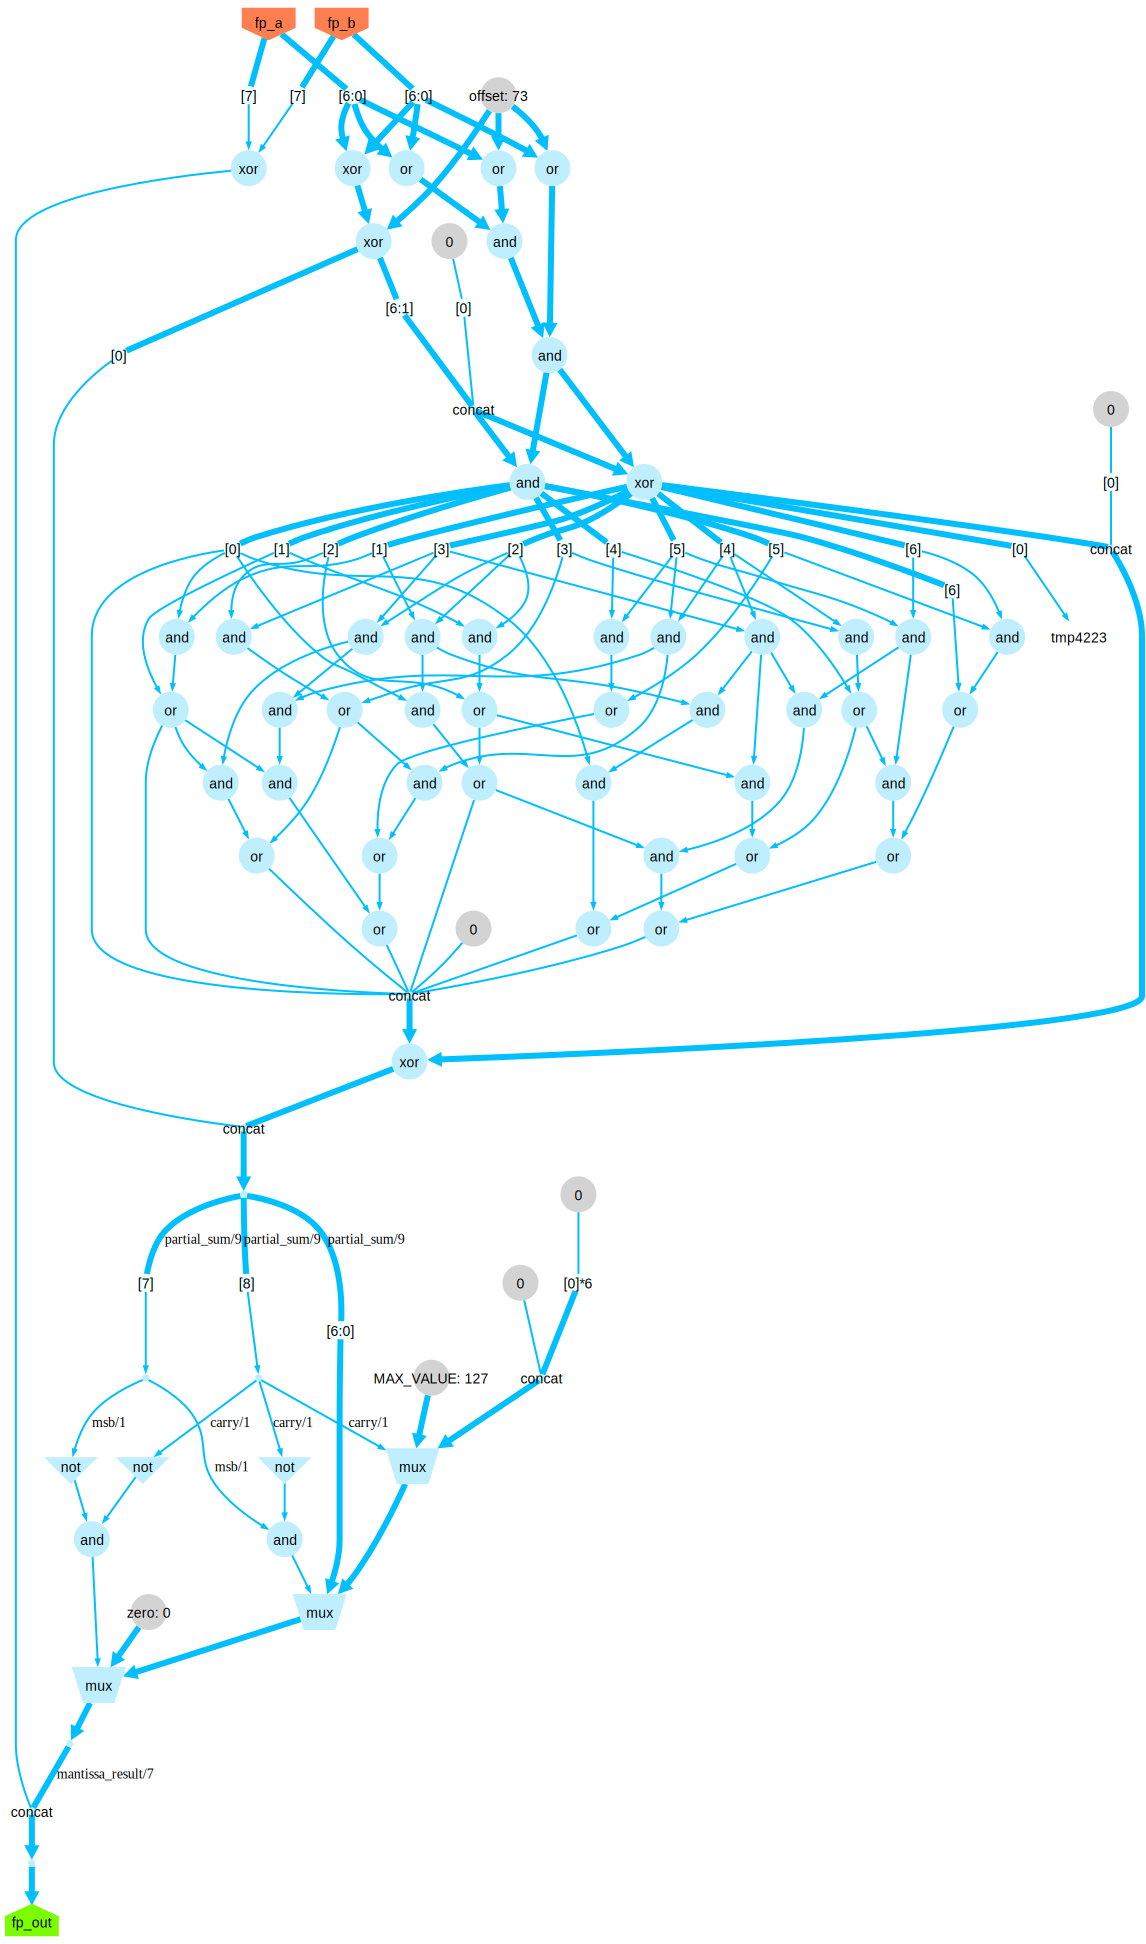

In [44]:
def get_const_offset(e_bits, m_bits):
    total_bits = e_bits + m_bits
    bias = (2**(e_bits-1) - 1) << m_bits
    
    if m_bits <= 3:
        l = m_bits
    if m_bits == 4:
        l = 3
    if m_bits > 4:
        l = 4
    l = (1 << m_bits) >> l
    
    offset = twos_comp_repr(l-bias, total_bits)
    return offset

def lmul_rtl():
    # Inputs 
    fp_a = pyrtl.Input(8, 'fp_a')
    fp_b = pyrtl.Input(8, 'fp_b')
    fp_out = pyrtl.Output(8, 'fp_out')

    # Split into sign and exp_mantissa parts
    # sign_a = fp_a[7] 
    # sign_b = fp_b[7]
    # exp_mantissa_a = fp_a[0:7]
    # exp_mantissa_b = fp_b[0:7]

    # Calculate result sign
    result_sign = fp_a[7] ^ fp_b[7]

    # Add exp_mantissa parts using kogge_stone adder (faster than ripple)
    # exp_mantissa_sum = kogge_stone(exp_mantissa_a, exp_mantissa_b)
    
    # For E4M3: e_bits=4, m_bits=3
    # Get the combined offset-bias constant 
    OFFSET_MINUS_BIAS = pyrtl.Const(get_const_offset(4, 3), bitwidth=7, name='offset')
    
    # Add offset-bias value - this will be 8 bits including carry
    # final_sum = kogge_stone(exp_mantissa_sum, OFFSET_MINUS_BIAS)
    
    # final_sum = carrysave_adder(fp_a[0:7], fp_b[0:7], pyrtl.Const(get_const_offset(4, 3), bitwidth=7), final_adder=kogge_stone)
    final_sum = pyrtl.WireVector(bitwidth=9, name='partial_sum') 
    # final_sum <<= fp_a[0:7] + fp_b[0:7] + pyrtl.Const(get_const_offset(4, 3), bitwidth=7)
    final_sum <<= carrysave_adder(fp_a[0:7], fp_b[0:7], OFFSET_MINUS_BIAS, final_adder=kogge_stone)
    # final_sum = carrysave_adder(fp_a[0:7], fp_b[0:7], OFFSET_MINUS_BIAS, final_adder=kogge_stone)

    # Extract carry and MSB for overflow/underflow detection
    carry, msb = pyrtl.WireVector(1, 'carry'), pyrtl.WireVector(1, 'msb')
    carry <<= final_sum[8]  # 9th bit
    msb <<= final_sum[7]    # 8th bit
    # final_sum <<= final_sum.truncate(7)

    # result_bits = final_sum[0:7]  # lower 7 bits
    mantissa_result = pyrtl.WireVector(7, 'mantissa_result')

    # Select result based on carry and MSB:
    # carry=1: overflow -> 0x7F
    # carry=0, msb=0: underflow -> 0x00
    # carry=0, msb=1: normal -> result_bits
    # MAX_VALUE = pyrtl.Const(0x7F, 7)
    
    with pyrtl.conditional_assignment:
        with carry:
            mantissa_result |= pyrtl.Const(0x7F, 7, name='MAX_VALUE')
        with msb:
            mantissa_result |= final_sum[0:7]
        with pyrtl.otherwise:
            mantissa_result |= pyrtl.Const(0, 7, name='zero')

    # Combine sign and result
    fp_out <<= pyrtl.concat(result_sign, mantissa_result)

    return fp_a, fp_b, fp_out

# Create the hardware
pyrtl.reset_working_block()
fp_a, fp_b, fp_out = lmul_rtl()

svg = pyrtl.block_to_svg()
display_svg(svg, raw=True)

In [45]:
pyrtl.synthesize()

# Generating timing analysis information
print("Pre Optimization:")
timing = pyrtl.TimingAnalysis()
timing.print_max_length()
logic_area, mem_area = pyrtl.area_estimation(tech_in_nm=65)
est_area = logic_area + mem_area
print("Estimated Area of block", est_area, "sq mm")
print()

pyrtl.optimize()

print("Post Optimization:")
timing = pyrtl.TimingAnalysis()
timing.print_max_length()
logic_area, mem_area = pyrtl.area_estimation(tech_in_nm=65)
est_area = logic_area + mem_area
print("Estimated Area of block", est_area, "sq mm")
print()

Pre Optimization:
The total block timing delay is  1745.2399999999998
Estimated Area of block 0.000442134 sq mm

Post Optimization:
The total block timing delay is  1498.07
Estimated Area of block 0.00026136 sq mm



In [62]:
from pyrtl.importexport import output_to_verilog

In [66]:
with open('lmul.v', 'w') as f:
    output_to_verilog(dest_file=f, block=pyrtl.working_block())